# Clustering & judge exploration

Quick visual sweep over (a) the per-sector clustering outputand (b) the LLM-as-judge results.


In [3]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Walk up from CWD to find the repo root (marker: top-level pyproject.toml
# that declares the policy-analysis-workspace project) and add it to sys.path.
_here = Path.cwd().resolve()
REPO_ROOT = None
for _p in [_here, *_here.parents]:
    pp = _p / 'pyproject.toml'
    if pp.exists() and 'policy-analysis-workspace' in pp.read_text():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        REPO_ROOT = _p
        break
if REPO_ROOT is None:
    raise RuntimeError('could not locate repo root from cwd')

from policy_analysis.clustering.eval.loader import load_clusters
from policy_analysis.clustering.eval.intrinsic import compute_intrinsic

DATA_ROOT = Path.home() / 'data' / 'wsl_sufficiency_eval' / 'clusters_2026-03-18'
RUN_DIR = REPO_ROOT / 'runs' / 'eval_v0'

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['figure.dpi'] = 110


## 1. Load clusters

In [4]:
df = load_clusters(DATA_ROOT)
print(f"rows: {len(df):,}")
print(f"sectors: {df['sector'].nunique()}")
print(f"global clusters: {df['cluster_uid'].nunique():,}")
df.head(3)

rows: 1,465,440
sectors: 11
global clusters: 1,030


,openalex_id,chunk_idx,policy_text,cluster_id,representative,sector,cluster_uid
0,W1000499890,1,"Include local, not ICT-based, electronic solut...",0,False,BUILDING,BUILDING__0
1,W1000499890,1,Include small-scale renewable integration in b...,1,False,BUILDING,BUILDING__1
2,W100238094,0,Regulation for organic farming requires more p...,2,False,BUILDING,BUILDING__2


In [21]:
str(df[:3]["policy_text"][1])

'Include small-scale renewable integration in buildings'

## 2. Cluster counts and sizes per sector

In [5]:
intrinsic = compute_intrinsic(df)

per_sector = (
    pd.DataFrame(intrinsic["per_sector"]).T
    .sort_values("n_clusters", ascending=False)
)
per_sector[["n_clusters", "n_items", "median", "max", "largest_cluster_fraction"]]

,n_clusters,n_items,median,max,largest_cluster_fraction
LOGISTICS,134.0,9132.0,26.0,339.0,0.037122
SOCIAL,111.0,438265.0,3404.0,10931.0,0.024942
FOOD,94.0,259960.0,2452.0,9527.0,0.036648
ENERGY,91.0,140360.0,1473.0,4054.0,0.028883
INDUSTRY,90.0,102791.0,1131.0,2820.0,0.027434
NATURE,90.0,207524.0,2331.0,6160.0,0.029683
MACROECONOMIC,88.0,24695.0,255.0,903.0,0.036566
URBAN,87.0,120788.0,1237.0,4791.0,0.039665
BUILDING,84.0,48915.0,591.0,1637.0,0.033466
MATERIALS,82.0,50261.0,654.0,1606.0,0.031953


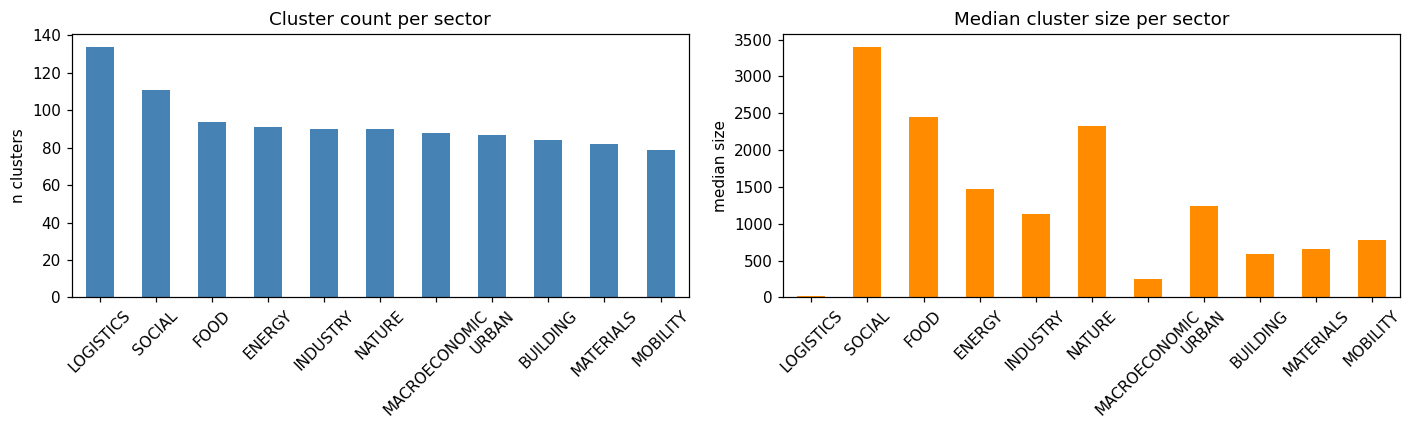

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
per_sector["n_clusters"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Cluster count per sector")
axes[0].set_ylabel("n clusters")

per_sector["median"].plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Median cluster size per sector")
axes[1].set_ylabel("median size")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

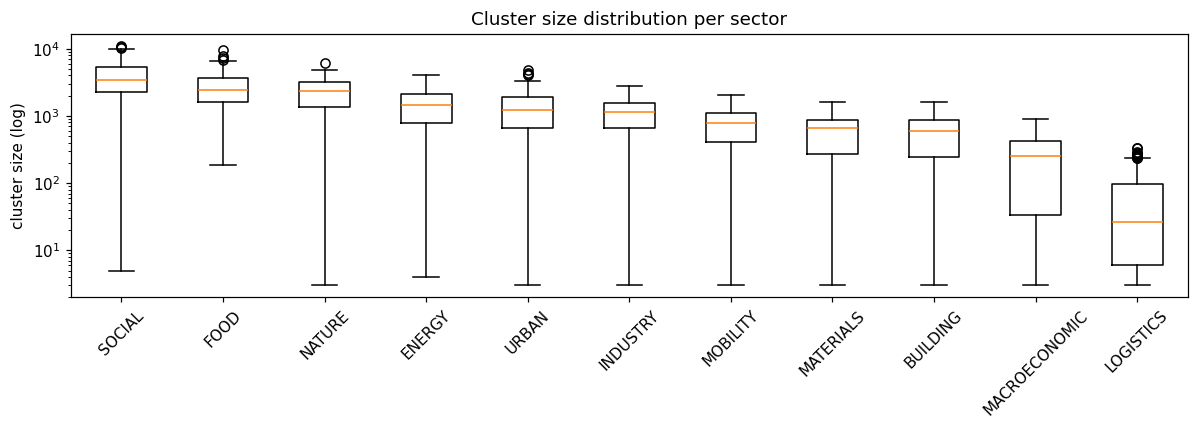

In [7]:
# Cluster-size distribution: violin-like via boxplot on log scale (one box per sector).
sizes_by_sector = {
    sector: sub.groupby("cluster_id").size().values
    for sector, sub in df.groupby("sector")
}
order = sorted(sizes_by_sector, key=lambda s: -np.median(sizes_by_sector[s]))
fig, ax = plt.subplots(figsize=(11, 4))
ax.boxplot([sizes_by_sector[s] for s in order], tick_labels=order, vert=True, showfliers=True)
ax.set_yscale("log")
ax.set_ylabel("cluster size (log)")
ax.set_title("Cluster size distribution per sector")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

## 3. Sample medoid texts

Skim the top-5 biggest clusters per sector to get a feel for what each cluster is about.

In [8]:
reps = df[df["representative"]].copy()
reps["size"] = reps["cluster_uid"].map(df.groupby("cluster_uid").size())

for sector in sorted(df["sector"].unique()):
    print(f"\n=== {sector} — top 5 clusters by size ===")
    top = reps[reps["sector"] == sector].sort_values("size", ascending=False).head(5)
    for _, r in top.iterrows():
        print(f"  [{int(r['size']):>5}]  {r['policy_text']}")


=== BUILDING — top 5 clusters by size ===
  [ 1637]  Affordable housing provision
  [ 1437]  Proper ventilation strategy in residences and offices
  [ 1252]  Implementation of seismic fortiﬁcation standards for buildings
  [ 1215]  Strategies for more inclusive housing
  [ 1192]  Incorporation of thermal insulation in the envelope

=== ENERGY — top 5 clusters by size ===
  [ 4054]  Establishment of carbon emissions trading market
  [ 3812]  Implementing appropriate policies and check-ups for solar PV energy sector
  [ 3694]  Implementation of resource-saving technologies in heat supply
  [ 3678]  Regulation of key air pollutants
  [ 3574]  Grid capacity and integration into electricity distribution grids

=== FOOD — top 5 clusters by size ===
  [ 9527]  Regulation of indiscriminate fishing
  [ 7737]  Improving availability of irrigation water
  [ 7283]  Intervention strategies promoting healthy dietary intake
  [ 6873]  Implementation of integrated pest management strategies
  [ 6679]

## 4. Judge results

Loads `runs/eval_v0/judgments.jsonl`. If it doesn't exist (you haven't run the judge yet), the rest of the notebook will skip itself.

In [9]:
judgments_path = RUN_DIR / "judgments.jsonl"
items_path = RUN_DIR / "intrusion_items.jsonl"

if not judgments_path.exists():
    print(f"no judgments at {judgments_path} — skipping judge sections")
    judg = None
    items_by_uid = {}
else:
    raw = [json.loads(l) for l in judgments_path.read_text().splitlines() if l.strip()]
    # Dedup: keep latest record per cluster_uid (matches report.py).
    by_uid = {r["cluster_uid"]: r for r in raw}
    judg = pd.DataFrame(by_uid.values())
    items_by_uid = {
        it["cluster_uid"]: it
        for it in (json.loads(l) for l in items_path.read_text().splitlines() if l.strip())
    }
    print(f"loaded {len(judg)} judgments")
    print(f"  errors: {(judg.get('error').notna() if 'error' in judg else pd.Series([False]*len(judg))).sum()}")
    judg.head(3)

loaded 50 judgments
  errors: 0


In [10]:
if judg is not None:
    valid = judg[~judg.get("error", pd.Series([np.nan]*len(judg))).notna()].copy() if "error" in judg else judg.copy()
    valid["correct"] = valid["intruder_index"] == valid["gold_intruder_index"]
    print(f"n_valid = {len(valid)}")
    print(f"accuracy = {valid['correct'].mean():.3f}  (chance = 0.20)")
    print(f"mean confidence = {valid['confidence'].mean():.2f}")
    print(f"mean specificity = {valid['specificity'].mean():.2f}")
    if "error" in judg:
        err_rate = judg["error"].notna().mean()
        print(f"error rate = {err_rate:.1%}")

n_valid = 50
accuracy = 0.700  (chance = 0.20)
mean confidence = 4.86
mean specificity = 3.24


               n  accuracy
sector                    
BUILDING       2  0.500000
ENERGY         6  0.666667
FOOD           2  1.000000
INDUSTRY       6  1.000000
LOGISTICS      6  0.666667
MACROECONOMIC  5  0.800000
MATERIALS      4  0.500000
MOBILITY       1  1.000000
NATURE         5  0.400000
SOCIAL         6  0.666667
URBAN          7  0.714286
              n  accuracy
size_bucket              
large        35  0.771429
medium       11  0.545455
small         4  0.500000


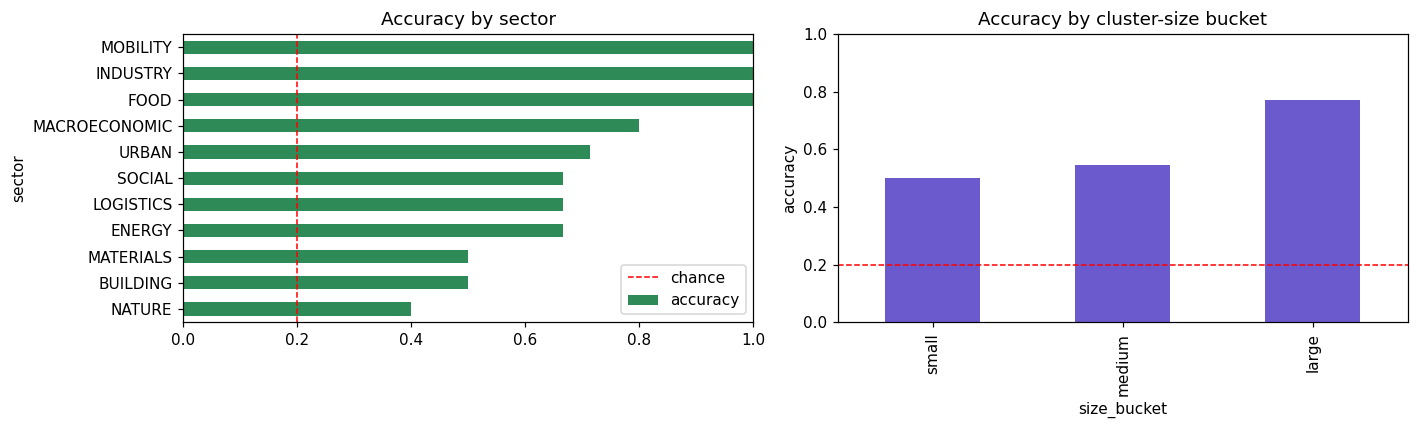

In [11]:
if judg is not None and len(valid) > 0:
    by_sector = valid.groupby("sector").agg(n=("correct", "size"), accuracy=("correct", "mean"))
    by_bucket = valid.groupby("size_bucket").agg(n=("correct", "size"), accuracy=("correct", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    by_sector["accuracy"].sort_values().plot.barh(ax=axes[0], color="seagreen")
    axes[0].axvline(0.2, color="red", ls="--", lw=1, label="chance")
    axes[0].set_xlim(0, 1)
    axes[0].set_title("Accuracy by sector")
    axes[0].legend()

    by_bucket["accuracy"].reindex(["small", "medium", "large"]).plot.bar(ax=axes[1], color="slateblue")
    axes[1].axhline(0.2, color="red", ls="--", lw=1)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Accuracy by cluster-size bucket")
    axes[1].set_ylabel("accuracy")
    plt.tight_layout()
    print(by_sector)
    print(by_bucket)

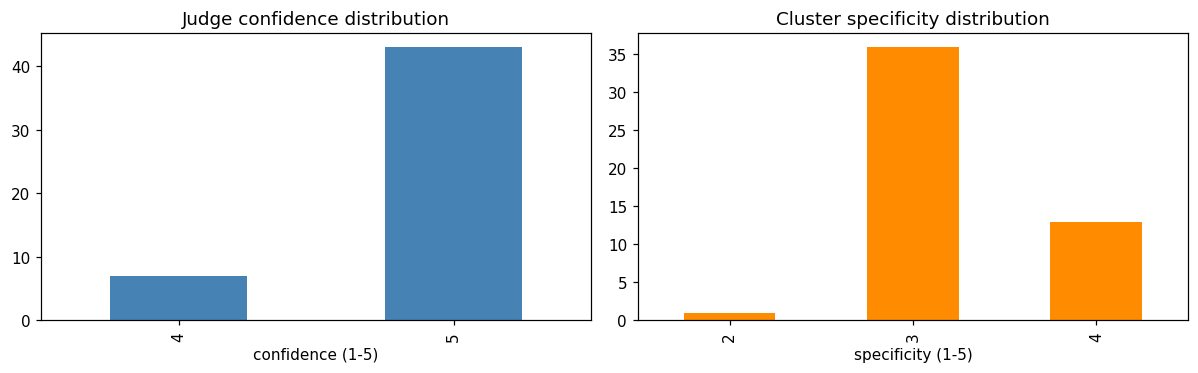

In [12]:
if judg is not None and len(valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    valid["confidence"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
    axes[0].set_title("Judge confidence distribution")
    axes[0].set_xlabel("confidence (1-5)")
    valid["specificity"].value_counts().sort_index().plot.bar(ax=axes[1], color="darkorange")
    axes[1].set_title("Cluster specificity distribution")
    axes[1].set_xlabel("specificity (1-5)")
    plt.tight_layout()

### Inspect wrong picks

Show the 5 statements + judge pick + gold for each mistake. This is the main qualitative read for prompt iteration.

In [13]:
if judg is not None and len(valid) > 0:
    wrong = valid[~valid["correct"]]
    print(f"{len(wrong)} wrong picks out of {len(valid)}\n")
    for _, row in wrong.head(10).iterrows():
        it = items_by_uid.get(row["cluster_uid"])
        if not it:
            continue
        print(f"--- {row['cluster_uid']}  sector={row['sector']}  size={row['cluster_size']}  conf={row['confidence']} ---")
        print(f"topic_label: {row.get('topic_label', '?')}")
        for i, c in enumerate(it["items"]):
            marks = []
            if i == row["gold_intruder_index"]: marks.append("GOLD")
            if i == row["intruder_index"]: marks.append("JUDGE")
            mark = f"  <- {','.join(marks)}" if marks else ""
            print(f"  [{i}] {c['text'][:150]}{mark}")
        print()

15 wrong picks out of 50

--- URBAN__42  sector=URBAN  size=353  conf=5 ---
topic_label: urban pandemic response policies
  [0] National and local policies and actions in London  <- GOLD
  [1] Land development plans and policies that account for the interplay between land use types, such as the expansion of Cropland and Grassland, to reduce   <- JUDGE
  [2] Multi-centric urban planning to increase health resilience during pandemics
  [3] Extremely stringent lockdown measures
  [4] Restricting the use of green spaces during pandemics to mitigate disease transmission

--- SOCIAL__43  sector=SOCIAL  size=2494  conf=5 ---
topic_label: culturally tailored health interventions
  [0] Engagement of traditional healers or birth attendants in the delivery of community-based maternal mental health services  <- GOLD
  [1] Comprehensive, culturally appropriate RMNH services
  [2] Culturally sensitive interventions
  [3] Embedding cultural tailoring systematically through content adaptation and the 

### Top topic labels

In [14]:
if judg is not None and len(valid) > 0:
    labels = valid["topic_label"].str.strip().str.lower().value_counts().head(30)
    print(labels.to_string())

topic_label
renewable energy policy                                        1
carbon emission quantification and accounting                  1
urban pandemic response policies                               1
culturally tailored health interventions                       1
sustainable supply chain management                            1
access to finance for smes and entrepreneurs                   1
transformational leadership and employee development           1
green finance development                                      1
eu economic growth and recovery strategies                     1
burnout prevention and measurement in professionals            1
urban ecological conservation and planning                     1
species and habitat conservation                               1
waste management and resource recovery                         1
financial inclusion and rural banking                          1
employee motivation and incentive programs                     1
gender-inclus

### Errors by sector (if any)

In [15]:
if judg is not None and "error" in judg.columns:
    err = judg[judg["error"].notna()]
    if len(err):
        print(f"{len(err)} errors")
        print(err.groupby("sector").size().sort_values(ascending=False).to_string())
        print("\nerror types:")
        print(err["error"].value_counts().to_string())